# 02 · Processed EDA: location and price
**Owner:** Pricing & Availability Lead · **Input:** `data/processed/resale_features.csv`, `block_features.csv` (steps 1b → 4)

**Question.** How does location (MRT, amenities) relate to price, *after* removing the things location is tangled up with?

**Method: the location premium.** For every sale we take log price per sqm and remove, in order:
1. the **month × flat type** average (so market timing and flat type drop out), then
2. **remaining lease, storey and flat model** (a small regression).

What is left, `premium`, is roughly *how much more (or less) this flat sold for than a comparable flat in the same month*.
`premium = 0.10` ≈ 10% above comparable flats. A second version, `premium_in_town`, also removes the town average, so it
compares blocks **within the same town**. That is the fairer test of MRT and amenity effects, because towns differ in many other ways.

These are descriptive patterns to guide the hedonic model, not causal estimates.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sys.path.insert(0, "../src")
import config as C

d = pd.read_csv(C.PROCESSED / "resale_features.csv", low_memory=False)
d = d[d["in_scope"] & ~d["psm_outlier"]].copy()
b = pd.read_csv(C.PROCESSED / "block_features.csv")
print(f"{len(d):,} in-scope sales (outliers excluded) · {d['address'].nunique():,} blocks")

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
DIVERGE = LinearSegmentedColormap.from_list("div", [ORANGE, "#f0efea", BLUE])      # discount <- neutral -> premium
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "axes.edgecolor": "#9a9a95", "axes.labelcolor": "#3d3d3a", "xtick.color": "#5c5c57",
                     "ytick.color": "#5c5c57", "lines.linewidth": 1.8, "legend.frameon": False, "font.size": 10})
pct = plt.FuncFormatter(lambda v, _: f"{v:+.0%}")

241,273 in-scope sales (outliers excluded) · 9,711 blocks


## 1 · Build the location premium

In [2]:
y = np.log(d["price_psm"])
y = y - y.groupby([d["month"], d["flat_type"]]).transform("mean")                 # remove timing x flat type
X = pd.concat([d[["remaining_lease_yrs", "storey_mid"]].assign(lease2=d["remaining_lease_yrs"] ** 2 / 100),
               pd.get_dummies(d["flat_model_group"], drop_first=True, dtype=float)], axis=1)
X = (X - X.mean()).to_numpy(float)
beta, *_ = np.linalg.lstsq(X, y.to_numpy(), rcond=None)
d["premium"] = y.to_numpy() - X @ beta                                            # what location (and noise) explains
d["premium_in_town"] = d["premium"] - d.groupby("town")["premium"].transform("mean")
print(f"Spread of the premium: 10th pct {d['premium'].quantile(.1):+.0%}, 90th pct {d['premium'].quantile(.9):+.0%}")
print(f"Share of premium variance explained by town alone: {1 - d['premium_in_town'].var() / d['premium'].var():.0%}")

Spread of the premium: 10th pct -18%, 90th pct +24%
Share of premium variance explained by town alone: 46%


**Finding:** _how much of the location premium is simply 'which town'?_

## 2 · Map of the premium
Each dot is a block, coloured by its average premium. Blue = sells above comparable flats, orange = below.

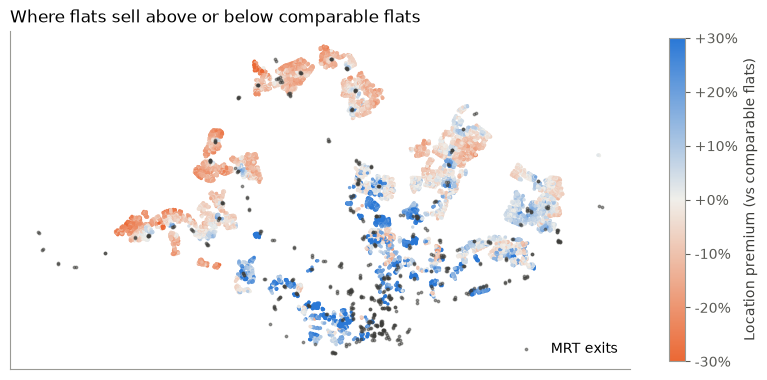

In [3]:
blk = d.groupby("address").agg(premium=("premium", "mean"), n=("premium", "size")).join(b.set_index("address")[["lat", "lon"]])
blk = blk[blk["n"] >= 3]
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(blk["lon"], blk["lat"], c=blk["premium"].clip(-0.3, 0.3), cmap=DIVERGE, vmin=-0.3, vmax=0.3, s=6, linewidths=0)
mrt = pd.read_csv(C.AMENITY_POINTS).query("type == 'mrt_exit'")
ax.scatter(mrt["lon"], mrt["lat"], s=3, color="#3d3d3a", alpha=0.5, label="MRT exits")
cb = fig.colorbar(sc, ax=ax, shrink=0.7, format=pct); cb.set_label("Location premium (vs comparable flats)")
ax.set_aspect("equal"); ax.grid(False); ax.set_xticks([]); ax.set_yticks([]); ax.legend(loc="lower right")
ax.set_title("Where flats sell above or below comparable flats", loc="left"); plt.show()

**Finding:** _the geography: a city-centre gradient? Local hot spots around MRT lines?_

## 3 · MRT distance
Average premium by distance to the nearest MRT **at the time of sale** (100 m bands, up to 2 km).
Two lines: across Singapore, and within the same town.

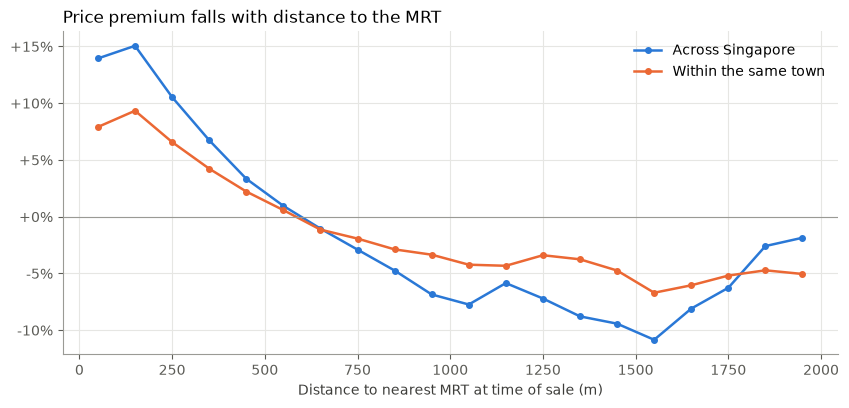

         all_sg  in_town      n
mrt_bin                        
50        0.139    0.079   3134
450       0.033    0.022  26338
950      -0.069   -0.033  12568
1450     -0.094   -0.047   4057
1950     -0.019   -0.050   1848


In [4]:
bins = np.arange(0, 2100, 100)
d["mrt_bin"] = pd.cut(d["dist_mrt_at_sale_m"], bins, labels=bins[:-1] + 50)
g = d.groupby("mrt_bin", observed=True).agg(all_sg=("premium", "mean"), in_town=("premium_in_town", "mean"), n=("premium", "size"))
fig, ax = plt.subplots()
ax.plot(g.index.astype(float), g["all_sg"], color=BLUE, marker="o", markersize=4, label="Across Singapore")
ax.plot(g.index.astype(float), g["in_town"], color=ORANGE, marker="o", markersize=4, label="Within the same town")
ax.axhline(0, color="#9a9a95", linewidth=0.8)
ax.yaxis.set_major_formatter(pct); ax.set_xlabel("Distance to nearest MRT at time of sale (m)")
ax.set_title("Price premium falls with distance to the MRT", loc="left"); ax.legend(); plt.show()
print(g.round(3).iloc[[0, 4, 9, 14, 19]].to_string())

**Finding:** _premium near vs far; is the drop steepest in the first 300–500 m? Does it survive within towns? This shapes the MRT term in the hedonic model (log distance, or bands?)._

## 4 · Do new stations show up in prices?
Blocks whose nearest station **opened during 2017–2026** (DTL3, Thomson–East Coast, Canberra, Punggol Coast, Hume),
were more than 300 m further from an MRT before it opened, and are within 800 m of it now.
Average within-town premium by year relative to the opening. Prices often move at **announcement or construction**, not opening.

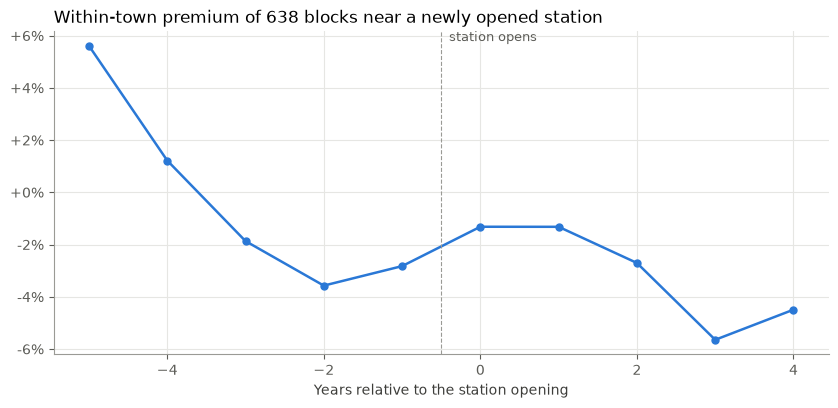

            premium     n
event_year               
-5.0          0.056   340
-4.0          0.012   503
-3.0         -0.019   614
-2.0         -0.036   566
-1.0         -0.028  1447
 0.0         -0.013  1497
 1.0         -0.013  1354
 2.0         -0.027  1286
 3.0         -0.056  1407
 4.0         -0.045  1311


In [5]:
op = pd.read_csv(C.MRT_OPENINGS)
op["key"] = op["station"].str.lower(); opened = dict(zip(op["key"], pd.to_datetime(op["opened"])))
e = d[d["nearest_mrt_now"].isin(opened) & (d["dist_mrt_now_m"] <= 800)].copy()
first_gap = (e["dist_mrt_at_sale_m"] - e["dist_mrt_now_m"]).groupby(e["address"]).max()
e = e[e["address"].isin(first_gap[first_gap > 300].index)]
e["event_year"] = ((pd.to_datetime(e["month"] + "-01") - e["nearest_mrt_now"].map(opened)).dt.days / 365.25).apply(np.floor)
ev = e[e["event_year"].between(-5, 4)].groupby("event_year").agg(premium=("premium_in_town", "mean"), n=("premium_in_town", "size"))
fig, ax = plt.subplots()
ax.plot(ev.index, ev["premium"], color=BLUE, marker="o", markersize=5)
ax.axvline(-0.5, color="#9a9a95", linewidth=0.8, linestyle="--"); ax.text(-0.4, ax.get_ylim()[1], "station opens", va="top", fontsize=9, color="#5c5c57")
ax.yaxis.set_major_formatter(pct); ax.set_xlabel("Years relative to the station opening")
ax.set_title(f"Within-town premium of {e['address'].nunique()} blocks near a newly opened station", loc="left"); plt.show()
print(ev.round(3).to_string())

**Finding:** _is there a visible step at opening, a gradual rise before it, or nothing? This tells you whether MRT-at-time-of-sale matters, or whether buyers price stations in early._

## 5 · Amenities, within the same town
Each panel: average within-town premium by distance (or count). Flat lines mean little price association.

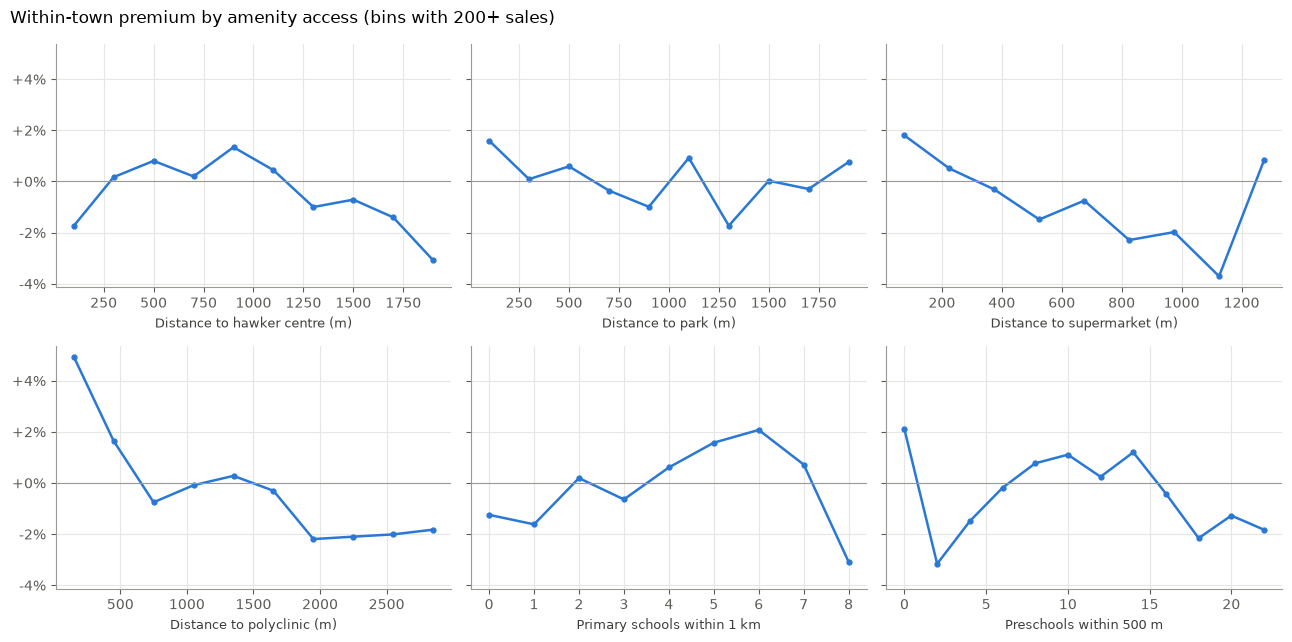

In [6]:
panels = [("dist_hawker_m", "Distance to hawker centre (m)", np.arange(0, 2200, 200)),
          ("dist_park_m", "Distance to park (m)", np.arange(0, 2200, 200)),
          ("dist_supermarket_m", "Distance to supermarket (m)", np.arange(0, 1650, 150)),
          ("dist_polyclinic_m", "Distance to polyclinic (m)", np.arange(0, 3300, 300)),
          ("n_primary_1km", "Primary schools within 1 km", np.arange(-0.5, 9.5, 1)),
          ("n_preschool_500m", "Preschools within 500 m", np.arange(-1, 25, 2))]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharey=True)
for ax, (col, label, edges) in zip(axes.flat, panels):
    s = d.groupby(pd.cut(d[col], edges), observed=True)["premium_in_town"].agg(["mean", "size"])
    s = s[s["size"] >= 200]
    ax.plot([iv.mid for iv in s.index], s["mean"], color=BLUE, marker="o", markersize=3.5)
    ax.axhline(0, color="#9a9a95", linewidth=0.8); ax.set_xlabel(label, fontsize=9); ax.yaxis.set_major_formatter(pct)
fig.suptitle("Within-town premium by amenity access (bins with 200+ sales)", x=0.01, ha="left"); fig.tight_layout(); plt.show()

**Finding:** _which amenities show a clear gradient, which are flat? Note any odd shapes (e.g. a premium for being *further* from a hawker centre can mean older estates cluster around hawker centres)._

## 6 · How correlated are the location features?
Block-level correlations. Pairs above about 0.7 will make individual effects hard to separate in the hedonic model; that's where SHAP helps.

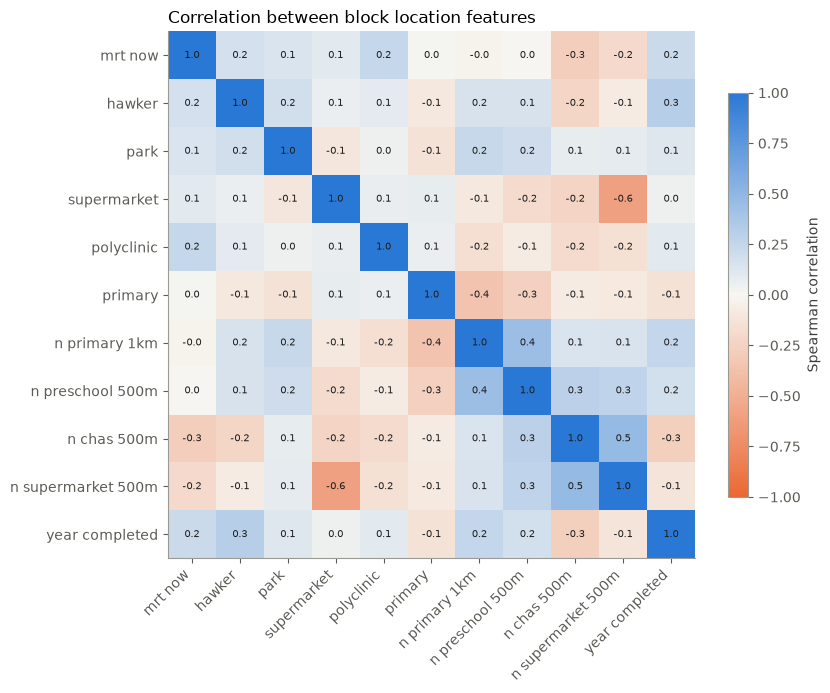

Strongest pairs:
dist_supermarket_m  n_supermarket_500m   -0.60
n_chas_500m         n_supermarket_500m    0.47
n_primary_1km       n_preschool_500m      0.44
dist_primary_m      n_primary_1km        -0.35
dist_hawker_m       year_completed        0.31


In [7]:
feats = ["dist_mrt_now_m", "dist_hawker_m", "dist_park_m", "dist_supermarket_m", "dist_polyclinic_m", "dist_primary_m",
         "n_primary_1km", "n_preschool_500m", "n_chas_500m", "n_supermarket_500m", "year_completed"]
corr = b[feats].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap=LinearSegmentedColormap.from_list("c", [ORANGE, "#f7f6f2", BLUE]), vmin=-1, vmax=1)
labels = [f.replace("dist_", "").replace("_m", "").replace("_", " ") for f in feats]
ax.set_xticks(range(len(feats))); ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticks(range(len(feats))); ax.set_yticklabels(labels)
for i in range(len(feats)):
    for j in range(len(feats)):
        ax.text(j, i, f"{corr.iloc[i, j]:.1f}", ha="center", va="center", fontsize=7.5, color="#1f1f1f")
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.75, label="Spearman correlation")
ax.set_title("Correlation between block location features", loc="left"); plt.show()
pairs = corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack()
print("Strongest pairs:"); print(pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(5).round(2).to_string())

**Finding:** _which features overlap? Consider dropping or combining one of each strongly correlated pair._

## 7 · Should LRT count for the MRT band?
In LRT towns (Sengkang, Punggol, Bukit Panjang) many blocks are over 1 km from an MRT but next to an LRT station.
If buyers value LRT access, the within-town premium should fall with distance to the nearest MRT **or LRT**.

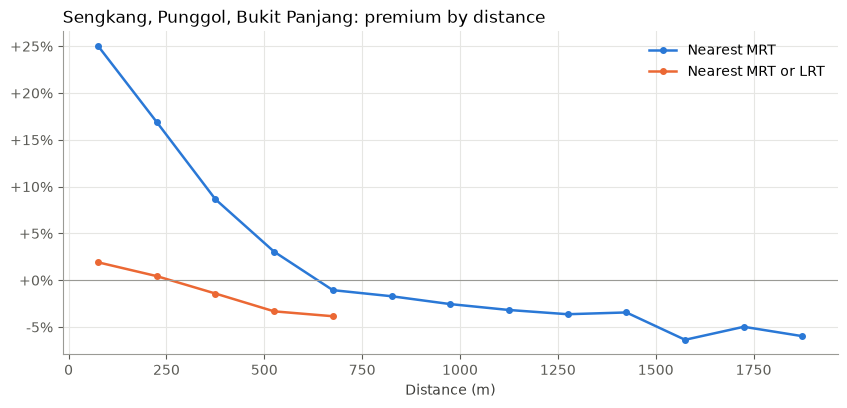

In [8]:
lrt_towns = ["SENGKANG", "PUNGGOL", "BUKIT PANJANG"]
x = d[d["town"].isin(lrt_towns)]
fig, ax = plt.subplots()
for col, label, c in [("dist_mrt_at_sale_m", "Nearest MRT", BLUE), ("dist_mrt_lrt_m", "Nearest MRT or LRT", ORANGE)]:
    s = x.groupby(pd.cut(x[col], np.arange(0, 2100, 150)), observed=True)["premium_in_town"].agg(["mean", "size"])
    s = s[s["size"] >= 100]
    ax.plot([iv.mid for iv in s.index], s["mean"], color=c, marker="o", markersize=4, label=label)
ax.axhline(0, color="#9a9a95", linewidth=0.8); ax.yaxis.set_major_formatter(pct); ax.legend()
ax.set_xlabel("Distance (m)"); ax.set_title("Sengkang, Punggol, Bukit Panjang: premium by distance", loc="left"); plt.show()

**Finding:** _which line shows the clearer gradient? If MRT-or-LRT is at least as strong, the team should use it for the MRT band (a one-line change in `config.py`/step 4)._

## 8 · Profile sparsity, now with the MRT band

In [9]:
p = pd.read_csv(C.OUTPUTS / "profiles.csv")
for k in [1, 5, 10, 20]:
    share = p.loc[p["n_last12"] >= k, "n_last12"].sum() / p["n_last12"].sum()
    print(f"{(p['n_last12'] >= k).mean():5.0%} of {len(p):,} profiles have {k}+ sales in the last 12 months (covering {share:.0%} of sales)")
thin = p[p["n_last12"].between(1, 4)]
print(f"\nThin profiles (1-4 sales a year) by flat type:"); print(thin["flat_type"].value_counts().to_string())
print("\nMRT band share of recent sales:", (p.groupby("mrt_band")["n_last12"].sum() / p["n_last12"].sum()).round(2).to_dict())

  80% of 1,927 profiles have 1+ sales in the last 12 months (covering 100% of sales)
  55% of 1,927 profiles have 5+ sales in the last 12 months (covering 95% of sales)
  37% of 1,927 profiles have 10+ sales in the last 12 months (covering 86% of sales)
  20% of 1,927 profiles have 20+ sales in the last 12 months (covering 68% of sales)

Thin profiles (1-4 sales a year) by flat type:
flat_type
5 ROOM       133
3 ROOM       104
4 ROOM       102
EXECUTIVE     79
2 ROOM        77

MRT band share of recent sales: {'500m-1km': 0.41, '<500m': 0.36, '>1km': 0.23}


**Finding:** _is sparsity acceptable? Thin profiles can borrow strength from the hedonic model (prices) and the Cox model (waits), so they need not be dropped. Agree this at the 9 Oct check-in._